## Import Required Libraries

In [38]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## Data Handler

In [26]:
def get_data(ticker, start_date, end_date):
    """
    Fetches historical stock data and returns it in a pandas DataFrame.
    """
    print(f"Fetching data for {ticker} from {start_date} to {end_date}...")
    df = yf.download(ticker, start=start_date, end=end_date)
    if df.empty:
        raise ValueError(f"No data found for ticker {ticker}. Check the ticker symbol.")
    print("Data fetched successfully.")
    return df

## Signal Generation

In [29]:
def generate_signals(df, short_window, long_window):
    """
    Generates trading signals based on a moving average crossover strategy.
    Returns the DataFrame with indicator and signal columns.
    """
    print("Generating trading signals...")
    # Create a new DataFrame to avoid modifying the original
    signals_df = df.copy()
    signals_df['signal'] = 0 # Start with a neutral signal

    # Calculate short and long moving averages
    signals_df['SMA_short'] = signals_df['Close'].rolling(window=short_window, min_periods=1).mean()
    signals_df['SMA_long'] = signals_df['Close'].rolling(window=long_window, min_periods=1).mean()

    # Generate the signal:
    # 1 for Buy (short-term SMA crosses above long-term SMA)
    # 0 for Hold
    # Note: We use np.where for a vectorized operation.
    signals_df['signal'] = np.where(signals_df['SMA_short'] > signals_df['SMA_long'], 1, 0)

    # To create entry/exit signals, we can take the difference from the previous day.
    # A change from 0 to 1 is a buy signal.
    # A change from 1 to 0 is a sell signal.
    signals_df['positions'] = signals_df['signal'].diff()
    print("Signals generated.")
    return signals_df

## Calculate Returns and Analyse Performance

In [32]:
def run_backtest_and_analyze(df):
    """
    Calculates returns and analyzes the performance of the strategy.
    Prints key metrics and plots the equity curve.
    """
    print("\n--- Running Backtest & Performance Analysis ---")
    backtest_df = df.copy()

    # --- Returns Calculation ---
    # 1. Calculate the daily returns of the asset (buy-and-hold benchmark)
    backtest_df['asset_returns'] = backtest_df['Close'].pct_change()

    # 2. Calculate the strategy's returns
    # We use .shift(1) on the signal to ensure we are only using information
    # available *before* the current day's price is known. This is crucial
    # to prevent look-ahead bias.
    backtest_df['strategy_returns'] = backtest_df['asset_returns'] * backtest_df['signal'].shift(1)

    # --- Performance Analysis ---
    # 1. Calculate cumulative returns for both the asset and the strategy
    backtest_df['cumulative_asset_returns'] = (1 + backtest_df['asset_returns']).cumprod() - 1
    backtest_df['cumulative_strategy_returns'] = (1 + backtest_df['strategy_returns']).cumprod() - 1

    # 2. Calculate Key Performance Metrics
    # (Ignoring risk-free rate for simplicity)
    final_strategy_return = backtest_df['cumulative_strategy_returns'].iloc[-1]
    final_asset_return = backtest_df['cumulative_asset_returns'].iloc[-1]

    # Sharpe Ratio
    sharpe_ratio = (backtest_df['strategy_returns'].mean() / backtest_df['strategy_returns'].std()) * np.sqrt(252)

    # Maximum Drawdown
    equity_curve = (1 + backtest_df['strategy_returns']).cumprod()
    peak = equity_curve.expanding(min_periods=1).max()
    drawdown = (equity_curve / peak) - 1
    max_drawdown = drawdown.min()

    print(f"\nFinal Strategy Return: {final_strategy_return:.2%}")
    print(f"Final Buy-and-Hold Return: {final_asset_return:.2%}")
    print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown:.2%}")

    # --- Visualization ---
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(12, 8))

    # Plot Equity Curves
    ( (1 + backtest_df['cumulative_strategy_returns']) * 100000 ).plot(label='Strategy Equity')
    ( (1 + backtest_df['cumulative_asset_returns']) * 100000 ).plot(label='Buy and Hold Equity')

    # Plot buy/sell signals on the equity curve
    plt.plot(backtest_df[backtest_df['positions'] == 1].index,
             (1 + backtest_df['cumulative_strategy_returns'][backtest_df['positions'] == 1]) * 100000,
             '^', markersize=10, color='g', lw=0, label='Buy Signal')

    plt.plot(backtest_df[backtest_df['positions'] == -1].index,
             (1 + backtest_df['cumulative_strategy_returns'][backtest_df['positions'] == -1]) * 100000,
             'v', markersize=10, color='r', lw=0, label='Sell Signal')

    plt.title('Strategy vs. Buy and Hold Equity Curve')
    plt.ylabel('Portfolio Value')
    plt.xlabel('Date')
    plt.legend()
    plt.show()

## Configuation and Execution

Fetching data for AAPL from 2020-01-01 to 2023-12-31...


/var/folders/r4/lt0cvy3d3b5ff5lbn8k4bb480000gn/T/ipykernel_38751/175838511.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Data fetched successfully.
Generating trading signals...
Signals generated.

--- Running Backtest & Performance Analysis ---

Final Strategy Return: 52.56%
Final Buy-and-Hold Return: 163.19%
Annualized Sharpe Ratio: 0.54
Maximum Drawdown: -23.77%


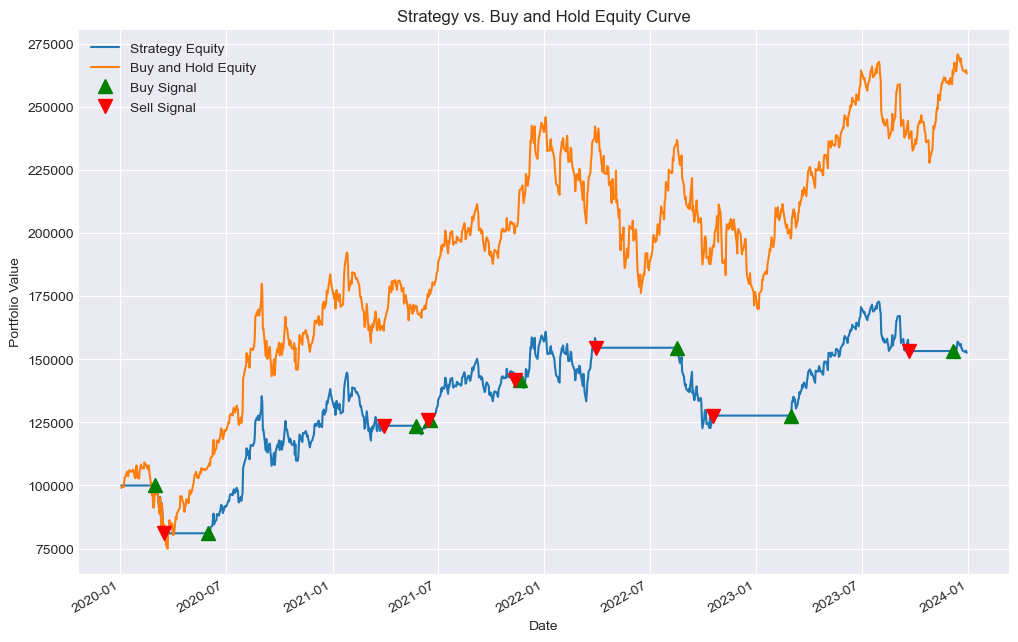

In [35]:
if __name__ == '__main__':
    # --- Configuration ---
    TICKER = 'AAPL'
    START_DATE = '2020-01-01'
    END_DATE = '2023-12-31'
    SHORT_WINDOW = 40
    LONG_WINDOW = 100

    # --- Workflow Execution ---
    # 1. Get Data
    price_data = get_data(TICKER, START_DATE, END_DATE)

    # 2. Generate Signals
    strategy_data = generate_signals(price_data, SHORT_WINDOW, LONG_WINDOW)

    # 3. Run Backtest and Analyze Performance
    run_backtest_and_analyze(strategy_data)